In [1]:
!pip install scikit-rf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 631.3/631.3 kB 8.8 MB/s eta 0:00:00


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Max bandwidth across amps: 0.842 GHz

V=4.0V , gain=19.2dB , ripple=3.07dB , slope=-4.94dB/GHz , detrended_std=1.176dB , μ_min=0.84 , stable=False , Bandwith=0.64123GHz , group_delay_std=0.494ns

V=4.2V , gain=19.8dB , ripple=3.02dB , slope=-6.82dB/GHz , detrended_std=0.809dB , μ_min=0.99 , stable=False , Bandwith=0.64222GHz , group_delay_std=0.345ns

V=4.4V , gain=19.8dB , ripple=3.09dB , slope=-6.90dB/GHz , detrended_std=0.475dB , μ_min=1.00 , stable=True , Bandwith=0.64321GHz , group_delay_std=0.423ns

V=4.6V , gain=19.4dB , ripple=3.12dB , slope=-6.48dB/GHz , detrended_std=0.395dB , μ_min=1.09 , stable=True , Bandwith=0.75521GHz , group_delay_std=0.511ns

V=4.8V , gain=19.1dB , ripple=3.03dB , slope=-6.02dB/GHz , detrended_std=0.449dB , μ_min=1.00 , stable=True , Bandwith=0.82954GHz , group_delay_std=0.371ns

V=4.9V , gain=19.1dB , ripple=2.99dB , slope=-

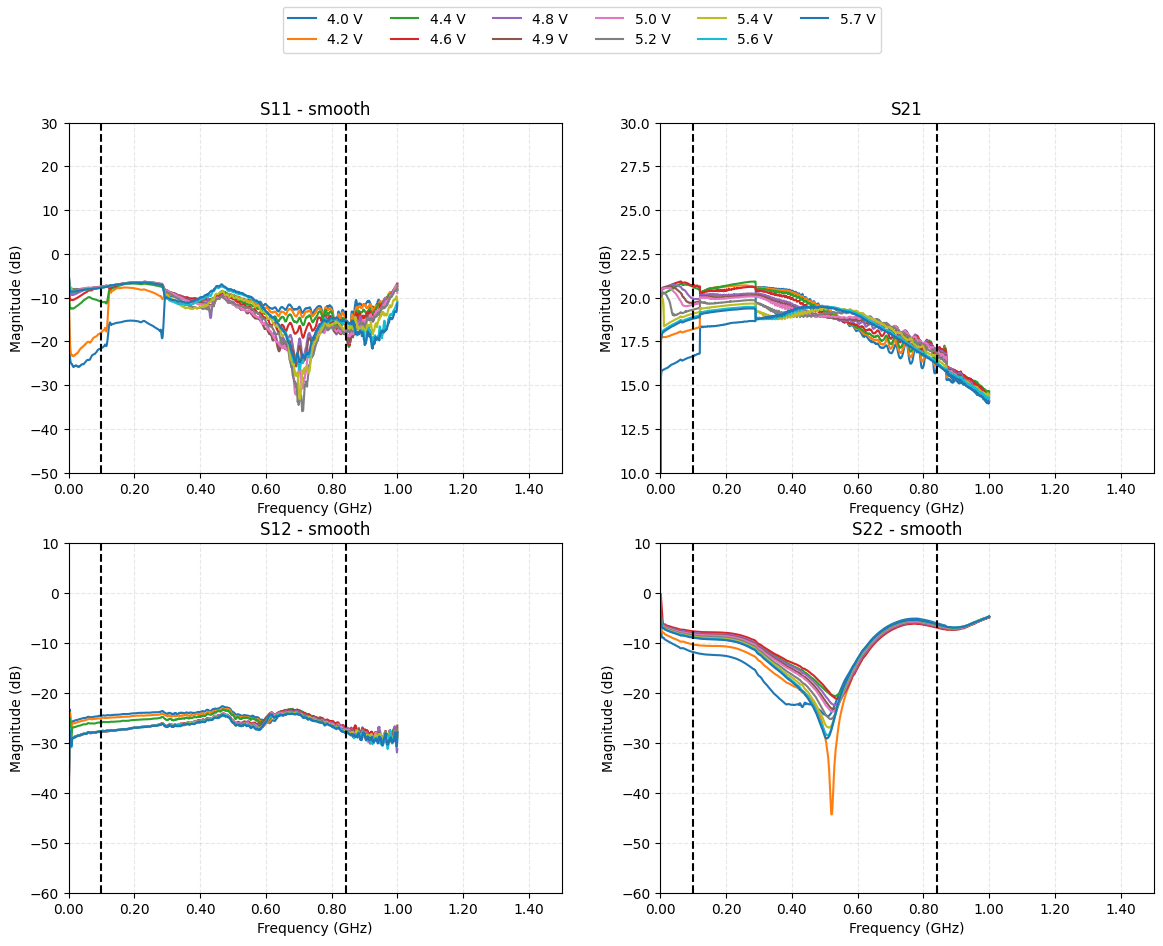

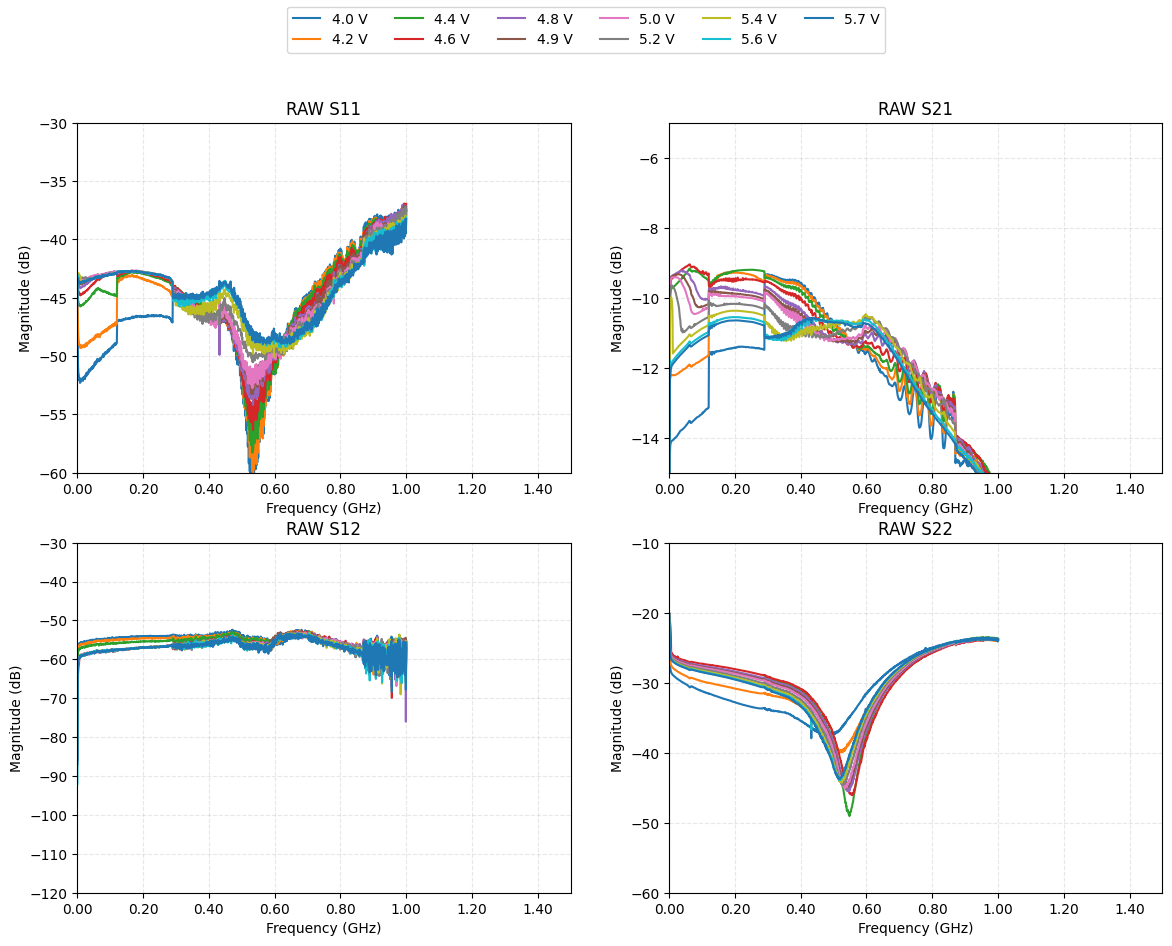

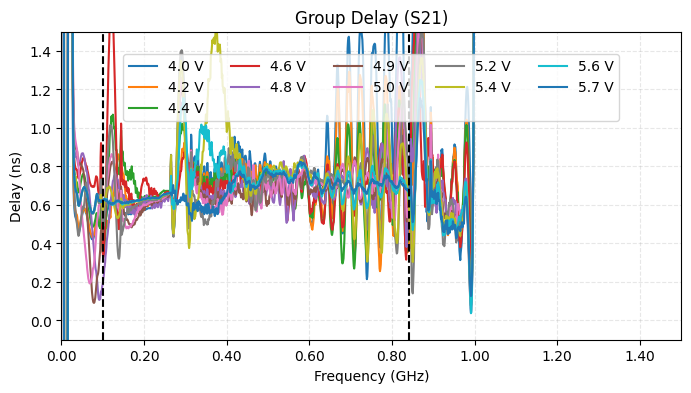

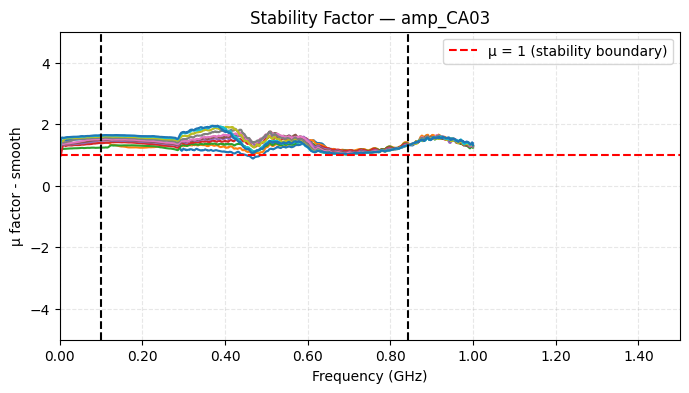

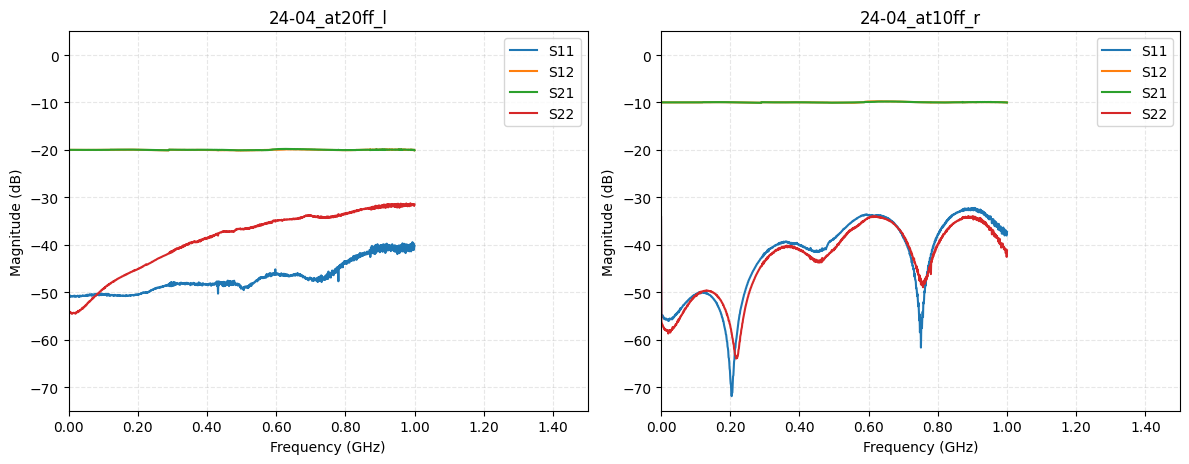

In [12]:
from google.colab import drive
drive.mount('/content/drive')

import os
import re
import csv
import numpy as np
import skrf as rf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.signal import savgol_filter
from scipy.ndimage import label as nd_label
# =========================================================
# CONFIG
# =========================================================

amp_name = "amp_CA03"

# ---- Attenuator mode ----
# "single"   → uses at20_name
# "separate" → uses at20_left_name, at20_mid_name, ff_name
at_left_mode = "single" # "separate" #

# ---- Attenuator filenames ----
# Older stuff:              at_left="29-03_at20_l",              at_right="29-03_at10_r"
# Early (CA, AA##_b):       at_left="24-04_at20ff_l",            at_right="24-04_at10ff_r"
# 1.5GHz +40dB single:      at_left="28-04_at20at20ff1.5G_l",    at_right="24-04_at10ff1.5G_r"
# 1.5GHz +20dB single:      at_left="24-04_at20ff1.5G_l",        at_right="24-04_at10ff1.5G_r"
# 1.5GHz +40dB average:     at_left="04-05_at20at20ff1.5Gavg_l", at_right="24-04_at10ff1.5G_r"
# v2 measurement (+10 left, +20+20 right): at_left="05-05_at20at10ff1.5Gavg_l", at_right="05-05_at20ff1.5Gavg_r"

# Used for separate measurements of attenuating fixtures
at_left_a_name = "04-05_at20leftff1.5G_l"
at_left_b_name = "04-05_at20midff1.5G_l"
ff_name        = "04-05_ff1.5G_l"

# Attenuators used in analysis, mode = single
at_left_name  = "24-04_at20ff_l"   # used if at_left_mode == "single"
at_right_name = "24-04_at10ff_r"


# ---- Folders ----
base_folder        = "/content/drive/My Drive/Colab Notebooks/LIP_VNA"
amp_folder         = os.path.join(base_folder, "Amplifiers", amp_name)
peripherals_folder = os.path.join(base_folder, "Peripherals")

# ---- Analysis ----
freq_min     = 1e8    # Hz — lower cutoff for gain/stability metrics
freq_max_plot = 1.5e9 # Hz — x-axis limit for plots
N_uniform    = 16384  # FFT export grid size (power of 2)

smoothing = "OFF"

# ---- Plot axis limits ----
ylim_raw_S11      = (-60, -30)
ylim_raw_S21      = (-15, -5)
ylim_raw_S12      = (-120, -30)
ylim_raw_S22      = (-60, -10)
ylim_S11          = (-50, 30)
ylim_S21          = (10, 30)
ylim_S12          = (-60, 10)
ylim_S22          = (-60, 10)
ylim_group_delay  = (-0.1, 1.5)
ylim_mu           = (-5, 5)

# ---- Scoring weights ----
w_detrended_std = 1.0
w_slope         = 0.3
w_ripple        = 0.2
w_gain          = 0.05

# =========================================================
# HELPERS
# =========================================================

def extract_voltage(filename):
    try:
        return float(filename.split('V')[0])
    except:
        return None

def base_key(filename):
    return re.sub(r'_[fb]\.s2p$', '', filename)

def merge_network(forward, backward):
    if len(forward.f) != len(backward.f):
        raise ValueError("Frequency mismatch between forward and backward files")
    s = np.zeros((len(forward.f), 2, 2), dtype=complex)
    s[:, 0, 0] = forward.s[:, 0, 0]
    s[:, 1, 0] = forward.s[:, 1, 0]
    s[:, 0, 1] = backward.s[:, 1, 0]
    s[:, 1, 1] = backward.s[:, 0, 0]
    return rf.Network(frequency=forward.frequency, s=s, z0=50*np.ones(2))

def compute_mu(s):
    S11, S12, S21, S22 = s[:,0,0], s[:,0,1], s[:,1,0], s[:,1,1]
    delta = S11*S22 - S12*S21
    mu = (1 - np.abs(S11)**2) / (
        np.abs(S22 - delta*np.conj(S11)) + np.abs(S12*S21)
    )
    return np.nan_to_num(mu)

def smooth(x, window=21, poly=5):
    window = min(window, len(x) - (1 if len(x) % 2 == 0 else 0))
    window = window if window % 2 == 1 else window - 1
    return savgol_filter(x, window_length=window, polyorder=poly)

def smooth_sparam_magphase(s, window=51, poly=5, db=True):
    """
    Smooth a single complex S-parameter using magnitude + phase.
    No artificial constraints — purely noise reduction.
    """
    mag = np.abs(s)
    phase = np.unwrap(np.angle(s))

    if db:
        mag_db = 20 * np.log10(mag + 1e-15)
        mag_db_s = smooth(mag_db, window, poly)
        mag_s = 10**(mag_db_s / 20)
    else:
        mag_s = smooth(mag, window, poly)

    phase_s = smooth(phase, window, poly)

    return mag_s * np.exp(1j * phase_s)


def smooth_network(ntw, window=51, poly=5
):
    """
    Smooth entire 2-port network consistently.
    No parameter is treated differently.
    """
    s = ntw.s
    s_smooth = np.zeros_like(s)

    for m in range(2):
        for n in range(2):
            s_smooth[:, m, n] = smooth_sparam_magphase(
                s[:, m, n],
                window=window,
                poly=poly
            )

    return rf.Network(
        frequency=ntw.frequency,
        s=s_smooth,
        z0=ntw.z0
    )


def apply_freq_format(ax):
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e9:.2f}"))
    ax.set_xlabel("Frequency (GHz)")


def format_ax(ax, title, xlim, ylim, ylabel=None):
    ax.set_title(title)
    ax.set_xlim(0, xlim)
    ax.set_ylim(*ylim)

    apply_freq_format(ax)

    if ylabel:
        ax.set_ylabel(ylabel)

    ax.grid(True, linestyle="--", alpha=0.3)

def extrapolate_to_dc_manual(ntw, n_fit=5):
    f = ntw.f
    s = ntw.s  # shape (N, 2, 2)

    s_dc = np.zeros((1, 2, 2), dtype=complex)

    for m in range(2):
        for n in range(2):
            mag_db = 20 * np.log10(np.abs(s[:n_fit, m, n]) + 1e-15)
            phase  = np.unwrap(np.angle(s[:n_fit, m, n]))

            p_mag   = np.polyfit(f[:n_fit], mag_db, 1)
            p_phase = np.polyfit(f[:n_fit], phase, 1)

            mag0   = 10**(np.polyval(p_mag, 0) / 20)
            phase0 = np.polyval(p_phase, 0)

            s_dc[0, m, n] = mag0 * np.exp(1j * phase0)

    f_new = np.concatenate(([0.0], f))
    s_new = np.concatenate((s_dc, s), axis=0)

    # Extend z0 by repeating its first row for the new DC point
    z0_new = np.concatenate((ntw.z0[:1], ntw.z0), axis=0)

    return rf.Network(frequency=rf.Frequency.from_f(f_new, unit='Hz'), s=s_new, z0=z0_new)

# =========================================================
# LOAD NETWORKS
# =========================================================
networks = {}
for folder in [amp_folder, peripherals_folder]:
    for f in os.listdir(folder):
        if f.endswith('.s2p'):
            networks[f] = rf.Network(os.path.join(folder, f))

amp_files = [f for f in os.listdir(amp_folder) if f.endswith('.s2p')]

# =========================================================
# BUILD ATTENUATORS
# =========================================================
merged_at_r = merge_network(
    networks[f"{at_right_name}_f.s2p"],
    networks[f"{at_right_name}_b.s2p"]
)

if at_left_mode == "separate":
    at_left_a_ff = merge_network(networks[f"{at_left_a_name}_f.s2p"], networks[f"{at_left_a_name}_b.s2p"])
    at_left_b_ff = merge_network(networks[f"{at_left_b_name}_f.s2p"], networks[f"{at_left_b_name}_b.s2p"])
    ff           = merge_network(networks[f"{ff_name}_f.s2p"],         networks[f"{ff_name}_b.s2p"])
    at_left_a    = at_left_a_ff ** ff.inv
    at_left_b    = at_left_b_ff ** ff.inv
    merged_at_l  = at_left_a ** at_left_b ** ff
else:
    merged_at_l = merge_network(
        networks[f"{at_left_name}_f.s2p"],
        networks[f"{at_left_name}_b.s2p"]
    )

if smoothing == "ON":
    merged_at_l = smooth_network(merged_at_l)
    merged_at_r = smooth_network(merged_at_r)

# =========================================================
# PAIR AMP FILES
# =========================================================
amp_files_f = [f for f in amp_files if "_f" in f]
amp_files_b = [f for f in amp_files if "_b" in f]
f_dict = {base_key(f): f for f in amp_files_f}
b_dict = {base_key(f): f for f in amp_files_b}
common_keys = sorted(set(f_dict.keys()) & set(b_dict.keys()))
amp_networks = {
    k: merge_network(networks[f_dict[k]], networks[b_dict[k]])
    for k in common_keys
}

# =========================================================
# FIGURES
# =========================================================
fig_s,   axes_s   = plt.subplots(2, 2, figsize=(14, 10))
fig_raw, axes_raw = plt.subplots(2, 2, figsize=(14, 10))
fig_gd,  ax_gd    = plt.subplots(figsize=(8, 4))
fig_mu,  ax_mu    = plt.subplots(figsize=(8, 4))
fig_att, ax_att   = plt.subplots(1, 2, figsize=(12, 5))

ax11, ax21 = axes_s[0];   ax12, ax22 = axes_s[1]
axr11, axr21 = axes_raw[0]; axr12, axr22 = axes_raw[1]

# =========================================================
# ATTENUATOR PLOTS
# =========================================================
merged_at_l.plot_s_db(ax=ax_att[0])
merged_at_r.plot_s_db(ax=ax_att[1])
apply_freq_format(ax_att[0])
apply_freq_format(ax_att[1])
ax_att[0].set_ylabel("Magnitude (dB)")
ax_att[1].set_ylabel("Magnitude (dB)")

ax_att[0].set_title(at_left_name if at_left_mode == "single" else "merged_at_l")
ax_att[1].set_title(at_right_name)
for ax in ax_att:
    ax.set_xlim(0, freq_max_plot)
    ax.grid(True, linestyle="--", alpha=0.3)
for ax in ax_att:
    format_ax(ax, ax.get_title(), freq_max_plot, (-75, 5), "Magnitude (dB)")

# =========================================================
# DEBUG ATTENUATOR PLOTS
# =========================================================
if at_left_mode == "separate":
    dbg_components = [
        (at_left_a_ff, f"{at_left_a_name} (raw)"),
        (at_left_b_ff, f"{at_left_b_name} (raw)"),
        (ff,           f"{ff_name}"),
        (at_left_a,    "at_left_a (ff removed)"),
        (at_left_b,    "at_left_b (ff removed)"),
        (merged_at_l,  "merged_at_l (final)"),
    ]
    fig_dbg, axes_dbg = plt.subplots(2, 3, figsize=(18, 10))

    for ax, (ntw, title) in zip(axes_dbg.flat, dbg_components):
        ntw.plot_s_db(ax=ax)
        format_ax(ax, title, freq_max_plot, (-75, 5))

    axes_dbg.flat[-1].cla()
    merged_at_r.plot_s_db(ax=axes_dbg.flat[-1])
    format_ax(axes_dbg.flat[-1], f"{at_right_name} (right)", freq_max_plot, (-75, 5))
    plt.tight_layout()
else:
    dbg_components = [(merged_at_l, f"{at_left_name} (combined)")]





# =========================================================
# ANALYSIS + PLOTTING LOOP
# =========================================================
results = []

for k, ntw in amp_networks.items():

    # De-embedding
    deembedded = merged_at_l.inv ** ntw ** merged_at_r.inv

    V     = extract_voltage(k)
    label = f"{V} V" if V is not None else k
    f     = deembedded.f
    s     = deembedded.s
    mask  = f >= freq_min

    # ---- Raw plots ----
    for (m, n), ax in [((0,0), axr11), ((1,0), axr21), ((0,1), axr12), ((1,1), axr22)]:
        ntw.plot_s_db(m=m, n=n, ax=ax, label=label, show_legend=False)
        apply_freq_format(ax)
        ax.set_ylabel("Magnitude (dB)")

    # ---- Export ----
    try:
        dut_dc = extrapolate_to_dc_manual(deembedded, n_fit=2)

        f_uniform   = np.linspace(0, dut_dc.frequency.f[-1], N_uniform)
        dut_uniform = dut_dc.interpolate(rf.Frequency.from_f(f_uniform, unit='Hz'))
        name        = f"{amp_name}_{V}V_uniform.s2p" if V is not None else k
        dut_uniform.write_touchstone(os.path.join(amp_folder, name))
    except Exception as e:
        print(f"[WARNING] Failed export for {k}: {e}")


    # ---- De-embedded S-parameter plots ----
    deembedded.plot_s_db(m=1, n=0, ax=ax21, label=label, show_legend=False)
    apply_freq_format(ax21)
    ax21.set_ylabel("Magnitude (dB)")
    for (m, n), ax in [((0,0), ax11), ((0,1), ax12), ((1,1), ax22)]:
        s_db = 20 * np.log10(np.abs(s[:, m, n]) + 1e-15)
        ax.plot(f, smooth(s_db), label=label)

    # ---- Group delay ----
    gd_full = np.abs(deembedded.group_delay[:, 1, 0]) * 1e9
    gd = gd_full[mask]
    f_masked = f[mask]

    ax_gd.plot(f, smooth(gd_full, window=51), label=label)

    # ---- Stability ----
    mu = compute_mu(s)
    ax_mu.plot(f, smooth(mu), label=label)

    # ---- Analysis metrics ----
    s21_db   = 20 * np.log10(np.abs(s[mask, 1, 0]) + 1e-15)
    freq_sel = f[mask] / 1e9
    p        = np.polyfit(freq_sel, s21_db, 1)
    trend    = np.polyval(p, freq_sel)
    residuals = s21_db - trend
    mu_masked = mu[mask]

    # ---- Bandwidth ----
    ref_bndwth = np.percentile(s21_db, 95)
    bw_threshold = ref_bndwth - 3
    bw_mask = s21_db >= bw_threshold

    # Region of interest (ROI) = inside bandwidth
    roi_s21 = s21_db[bw_mask]
    roi_residuals = residuals[bw_mask]
    roi_gd = gd[bw_mask]
    roi_mu = mu_masked[bw_mask]


    # Find contiguous regions
    labels, num = nd_label(~bw_mask)  # regions BELOW threshold

    bw_hz = f[mask][-1]  # fallback

    for i in range(1, num + 1):
        region = np.where(labels == i)[0]

        # Only consider regions in upper half
        if region[0] > len(s21_db) // 2:

            # Require minimum width (avoid noise dips)
            if len(region) > 10:   # tune this (5–20 points)

                bw_hz = f[mask][region[0]]
                break

    #print(f"  BW (-3dB from mean): {bw_hz/1e9:.3f} GHz")

    results.append({
        "V":                 V,
        "mean_gain":         np.mean(roi_s21),
        "std_gain":          np.std(roi_s21),
        "ripple":            np.ptp(roi_s21),
        "slope_dB_per_GHz":  p[0],                     # <-- REQUIRED
        "detrended_std":     np.std(roi_residuals),
        "detrended_ripple":  np.ptp(roi_residuals),
        "mu_min":            np.min(roi_mu),
        "mu_mean":           np.mean(roi_mu),
        "stable":            np.min(roi_mu) > 1,
        "bw_GHz":            round(bw_hz / 1e9, 5),
        "std_group_delay":   np.std(roi_gd),
        "score": (
            - w_detrended_std * np.std(roi_residuals)
            - w_slope         * abs(p[0])
            - w_ripple        * np.ptp(roi_s21)
            + w_gain          * np.mean(roi_s21)
            + round(bw_hz / 1e9, 3)
        )
    })


# =========================================================
# SORT + PRINT RESULTS
# =========================================================
#results.sort(key=lambda x: x["score"], reverse=True)

# ---- Global max bandwidth ----
bw_max_hz = max(r["bw_GHz"] for r in results) * 1e9
print(f"Max bandwidth across amps: {bw_max_hz/1e9:.3f} GHz")

for r in results:
    print(f"\nV={r['V']}V , gain={r['mean_gain']:.1f}dB , ripple={r['ripple']:.2f}dB , "
          f"slope={r['slope_dB_per_GHz']:.2f}dB/GHz , detrended_std={r['detrended_std']:.3f}dB , μ_min={r['mu_min']:.2f} , "
          f"stable={r['stable']} , Bandwith={r['bw_GHz']}GHz , group_delay_std={r['std_group_delay']:.3f}ns")
print("\n")
# =========================================================
# FORMATTING
# =========================================================
for ax, t, ylim, ylabel in zip(
    [ax11, ax21, ax12, ax22],
    ["S11 - smooth", "S21", "S12 - smooth", "S22 - smooth"],
    [ylim_S11, ylim_S21, ylim_S12, ylim_S22],
    ["Magnitude (dB)"] * 4
):
    format_ax(ax, t, freq_max_plot, ylim, ylabel)

handles, labels = ax21.get_legend_handles_labels()
fig_s.legend(handles, labels, loc='upper center', ncol=6)
plt.tight_layout(rect=[0, 0, 1, 0.95])

for ax, t, ylim_r in zip(
    [axr11, axr21, axr12, axr22],
    ["RAW S11", "RAW S21", "RAW S12", "RAW S22"],
    [ylim_raw_S11, ylim_raw_S21, ylim_raw_S12, ylim_raw_S22]
):
    format_ax(ax, t, freq_max_plot, ylim_r, "Magnitude (dB)")

fig_raw.legend(*axr11.get_legend_handles_labels(), loc='upper center', ncol=6)
plt.tight_layout(rect=[0, 0, 1, 0.95])

format_ax(ax_gd, "Group Delay (S21)", freq_max_plot, ylim_group_delay, "Delay (ns)")
ax_gd.set_xlabel("Frequency (GHz)")
ax_gd.set_ylabel("Delay (ns)")
ax_gd.legend(loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=5)

ax_mu.axhline(1, color='red', linestyle='--')
format_ax(ax_mu, f"Stability Factor — {amp_name}", freq_max_plot, ylim_mu, "μ factor")
ax_mu.set_xlabel("Frequency (GHz)")
ax_mu.set_ylabel("μ factor - smooth")
ax_mu.legend(
    [plt.Line2D([0], [0], color='red', linestyle='--')],
    ['μ = 1 (stability boundary)']
)

# ---- Vertical BW line ----
# Add labeled line only on S21
ax21.axvline(bw_max_hz, color='black', linestyle='--', linewidth=1.5, label='Max BW')
ax21.axvline(freq_min, color='black', linestyle='--', linewidth=1.5, label='Min FOI')

# Add unlabeled lines elsewhere
for ax in [ax11, ax12, ax22, ax_gd, ax_mu]:
    ax.axvline(bw_max_hz, color='black', linestyle='--', linewidth=1.5)
    ax.axvline(freq_min, color='black', linestyle='--', linewidth=1.5)


# =========================================================
# SAVE
# =========================================================
def save(fig, path):
    fig.savefig(path, format="pdf", bbox_inches="tight")
    print(f"Saved: {path}")

csv_path = os.path.join(amp_folder, f"results_{amp_name}.csv")
fieldnames = ["V", "mean_gain", "std_gain", "ripple", "slope_dB_per_GHz",
              "detrended_std", "detrended_ripple", "mu_min", "mu_mean",
              "stable", "bw_GHz", "std_group_delay", "score"]
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows({k: r[k] for k in fieldnames} for r in results)
print(f"Saved: {csv_path}")

# Save paths
save(fig_raw, os.path.join(amp_folder,         f"raw_{amp_name}.pdf"))
save(fig_s,   os.path.join(amp_folder,         f"deembedded_{amp_name}.pdf"))
save(fig_att, os.path.join(peripherals_folder, f"attenuators_{at_left_name}__{at_right_name}.pdf"))
if at_left_mode == "separate": save(fig_dbg, os.path.join(peripherals_folder, f"debug_attenuators_{amp_name}.pdf"))
save(fig_gd,  os.path.join(amp_folder,         f"group_delay_{amp_name}.pdf"))
save(fig_mu,  os.path.join(amp_folder,         f"stability_{amp_name}.pdf"))


plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
freq[-1] = 1.000 GHz
Nyquist = 100.0 GHz
mag_i max = 10.693, at freq = 0.317 GHz
mag_i[freq>10*freq[-1]] max = 0.065692
Pulse energy fraction above 5 GHz: 0.000000
OUT max: 8.175e+01, P max: 1.003e+01
mag_i overall max: 1.069e+01, min: 5.441e-04
Effective gain factor: 8.2372 (linear)
Expected peak (bandwidth-corrected): -411.86 mV
Input pulse peak:    -0.00 mV
Output pulse peak:   0.00 mV
Ratio: -inf
Input pulse peak:  -0.00 mV
Output pulse peak: 405.42 mV
Pulse sigma: 400 ps
Amp BW: 1.00 GHz
Pulse BW (1/2*pi*sigma): 0.40 GHz
mag[0] (DC gain, linear): 0.013 (-37.8 dB)
mag at band edge (linear): 5.333 (14.5 dB)
Input peak: 50.00 mV
Output peak: 405.42 mV
Implied amplitude gain: 8.11
peak time: 0.615 ns, peak value: 405.42 mV



/tmp/ipykernel_9298/3607902061.py:170: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"Ratio: {np.max(out_identity)/np.max(pulse):.6f}")


freq[-1] = 1.000 GHz
Nyquist = 100.0 GHz
mag_i max = 10.846, at freq = 0.256 GHz
mag_i[freq>10*freq[-1]] max = 0.066358
Pulse energy fraction above 5 GHz: 0.000000
OUT max: 9.943e+01, P max: 1.003e+01
mag_i overall max: 1.085e+01, min: 5.496e-04
Effective gain factor: 9.2242 (linear)
Expected peak (bandwidth-corrected): -461.21 mV
Input pulse peak:    -0.00 mV
Output pulse peak:   0.00 mV
Ratio: -inf
Input pulse peak:  -0.00 mV
Output pulse peak: 455.43 mV
Pulse sigma: 400 ps
Amp BW: 1.00 GHz
Pulse BW (1/2*pi*sigma): 0.40 GHz
mag[0] (DC gain, linear): 0.013 (-37.9 dB)
mag at band edge (linear): 5.387 (14.6 dB)
Input peak: 50.00 mV
Output peak: 455.43 mV
Implied amplitude gain: 9.11
peak time: 0.620 ns, peak value: 455.43 mV

freq[-1] = 1.000 GHz
Nyquist = 100.0 GHz
mag_i max = 11.119, at freq = 0.281 GHz
mag_i[freq>10*freq[-1]] max = 0.066513
Pulse energy fraction above 5 GHz: 0.000000
OUT max: 1.087e+02, P max: 1.003e+01
mag_i overall max: 1.112e+01, min: 5.509e-04
Effective gain fact

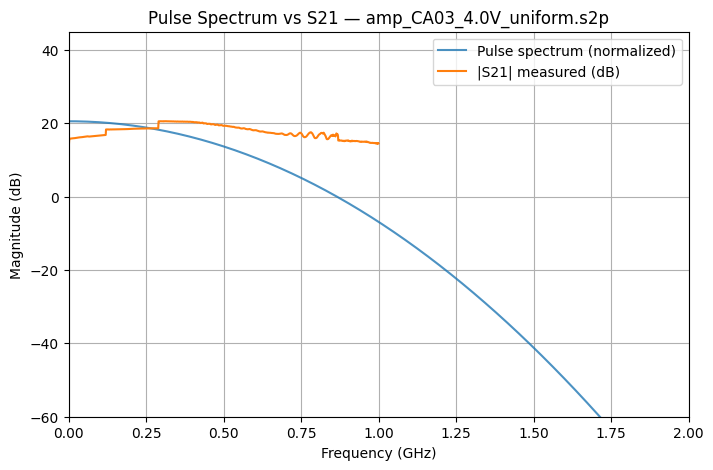

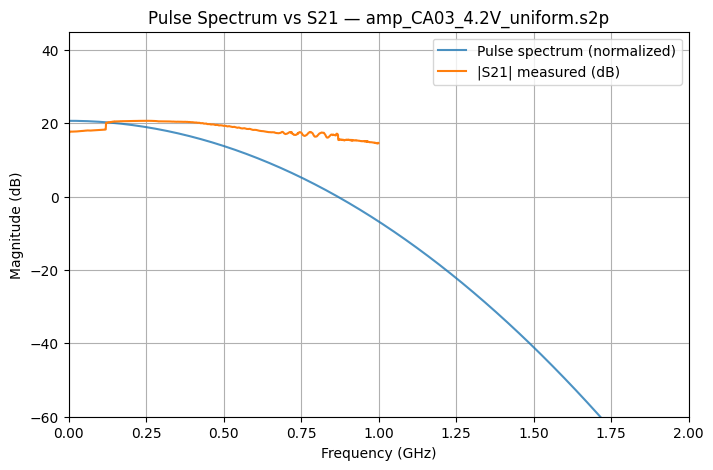

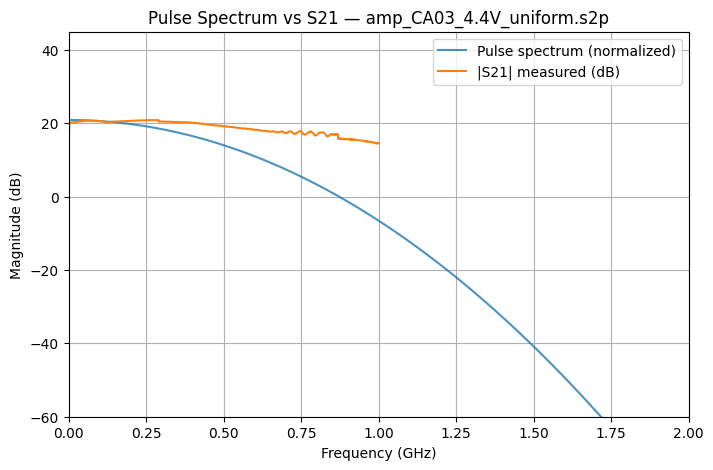

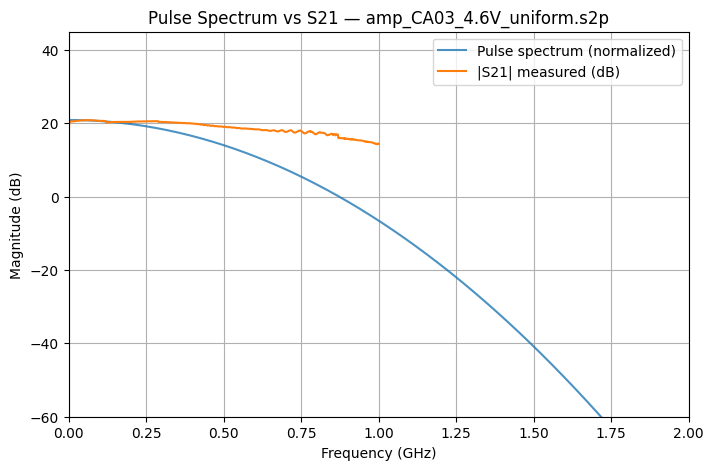

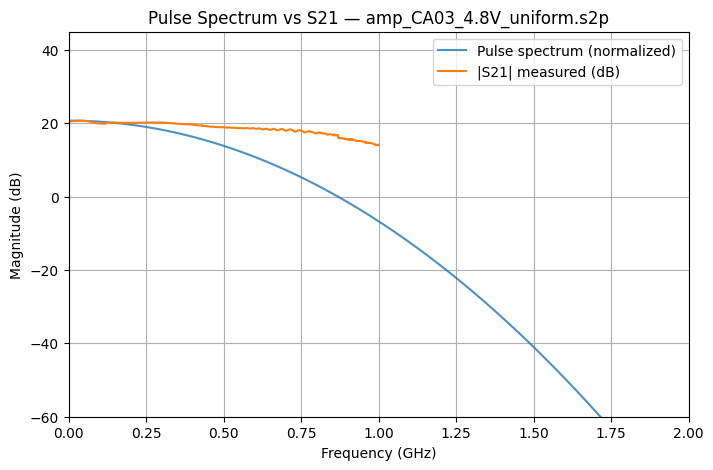

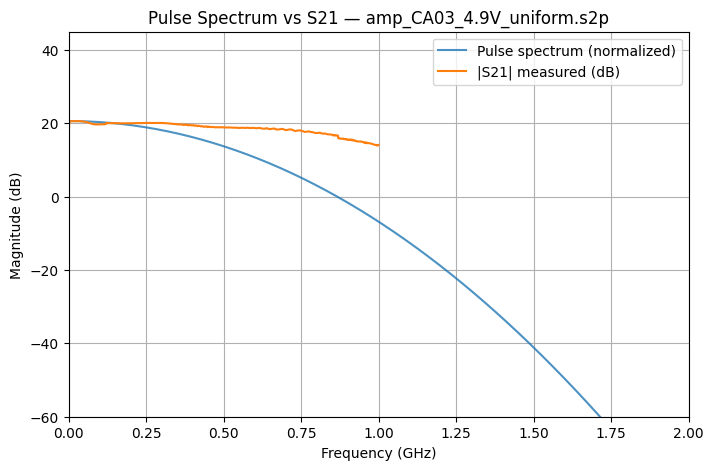

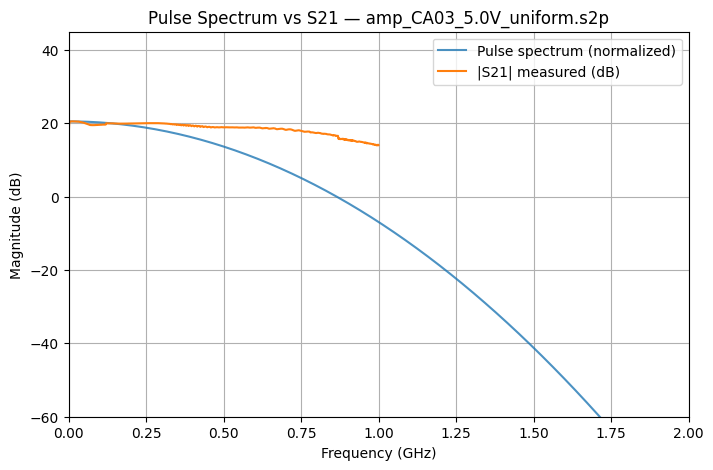

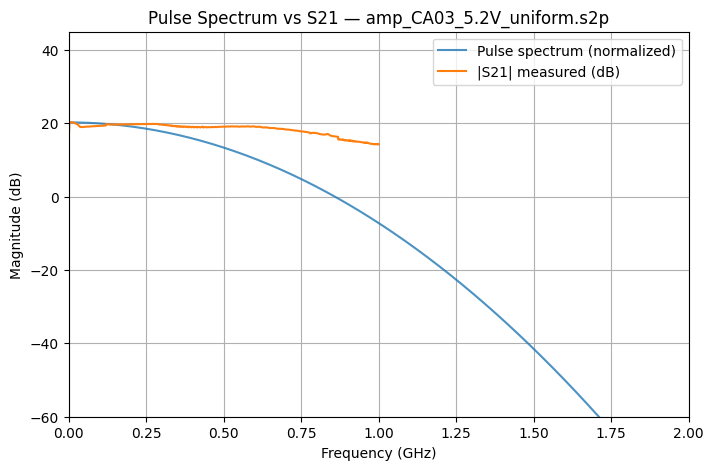

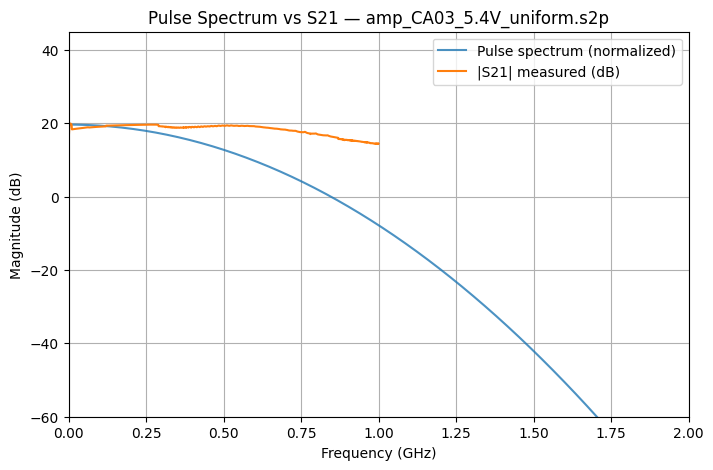

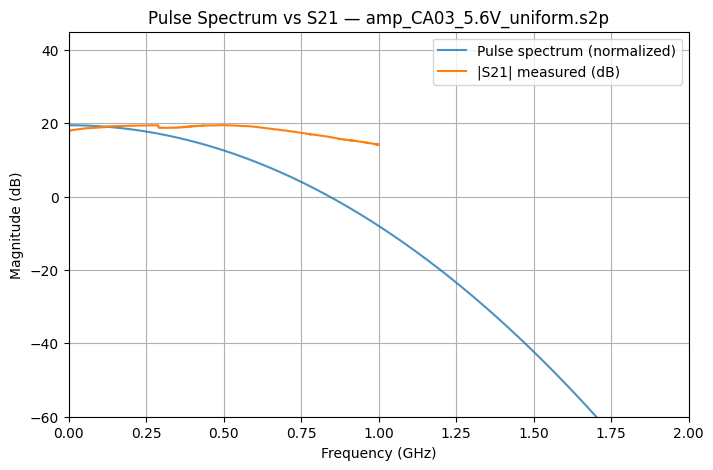

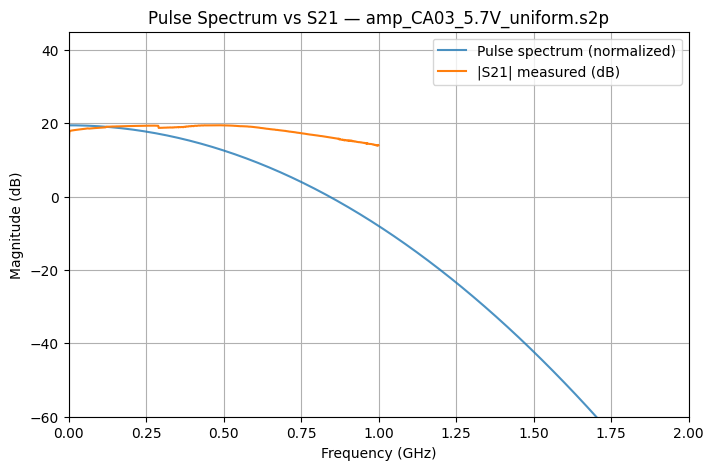

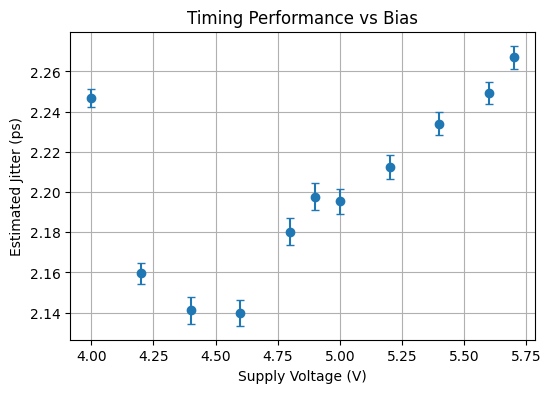

In [11]:
from google.colab import drive
drive.mount('/content/drive')
import os
import numpy as np
import re
import skrf as rf
import matplotlib.pyplot as plt
from scipy.signal.windows import tukey

# =========================================================
# CONFIG
# =========================================================
amp_name = "amp_CA03"

base_folder = "/content/drive/My Drive/Colab Notebooks/LIP_VNA"
amp_folder = os.path.join(base_folder, "Amplifiers", amp_name)

# ---- Pulse parameters ----
V0 = -50e-3          # mV peak
sigma = 400e-12     # ps gaussian std

# ---- Noise (measured with 100 MHz scope input value in uV, compute using V) ----
noise_rms_measured = 358*1e-6  # (Volts)

# Optional bandwidth correction
BW_scope = 100e6
BW_amp = 1.4e9
noise_rms = noise_rms_measured * np.sqrt(BW_amp / BW_scope)

# =========================================================
# LOAD FILES
# =========================================================
files = [f for f in os.listdir(amp_folder) if f.endswith("_uniform.s2p")]

#===========================
# Helpers
#===========================

# Interpolate on positive freqs only (group-delay-based extrapolation)
def interp_mag(f):
    f_abs = np.abs(f)
    m = np.interp(f_abs, freq, mag, left=mag[0], right=mag[-1])
    rolloff = np.where(
        f_abs <= freq[-1],
        1.0,
        1 / np.sqrt(1 + ((f_abs - freq[-1]) / freq[-1])**4)
    )
    return m * rolloff

def interp_phase(f):
    f_abs = np.abs(f)
    p_in_band = np.interp(f_abs, freq, phase, left=phase[0], right=phase[-1])

    # constant group delay extrapolation beyond measured band
    edge_slope = (phase[-1] - phase[-2]) / (freq[-1] - freq[-2])
    p_extrap = phase[-1] + edge_slope * (f_abs - freq[-1])

    p = np.where(f_abs <= freq[-1], p_in_band, p_extrap)

    # Negative frequencies get conjugate phase
    return np.where(f >= 0, p, -p)

def extract_vbias(filename):
    match = re.search(r'(\d+\.?\d*)V', filename)
    return float(match.group(1)) if match else None


results = []

# =========================================================
# CONSOLIDATED PULSE + FFT GRID (defined once, outside the loop)
# =========================================================
N = 16384
dt = 5e-12
t = (np.arange(N) - N // 2) * dt          # properly centered for even N
freqs = np.fft.fftfreq(N, d=dt)

pulse = V0 * np.exp(-t**2 / (2 * sigma**2))
P = np.fft.fft(pulse)

# =========================================================
# LOOP OVER AMPLIFIERS
# =========================================================
for f in files:

    path = os.path.join(amp_folder, f)
    ntwk = rf.Network(path)

    freq = ntwk.f
    S21 = ntwk.s[:, 1, 0]

    # =====================================================
    # INTERPOLATE S21 ONTO FFT GRID
    # =====================================================
    mag   = np.abs(S21)
    phase = np.unwrap(np.angle(S21))

    mag_i   = interp_mag(freqs)
    phase_i = interp_phase(freqs)

    S21_full = mag_i * np.exp(1j * phase_i)

    # =========================================================
    # FFT OF GAUSSIAN OVERLAID WITH S21
    # =========================================================
    P_dB = 20 * np.log10(np.abs(np.fft.fftshift(P)) + 1e-20)
    P_dB -= np.max(P_dB)  # normalize to 0 dB peak

    freq_shift = np.fft.fftshift(freqs)
    S21_dB = 20 * np.log10(np.abs(S21_full) + 1e-20)

    plt.figure(figsize=(8,5))
    plt.plot(freq_shift * 1e-9, P_dB + np.max(S21_dB), label="Pulse spectrum (normalized)", alpha=0.8)
    plt.plot(freq * 1e-9, 20*np.log10(mag), label="|S21| measured (dB)")
    plt.xlim(0, 2)
    plt.ylim(-60, 45)
    plt.xlabel("Frequency (GHz)")
    plt.ylabel("Magnitude (dB)")
    plt.title(f"Pulse Spectrum vs S21 — {f}")
    plt.grid(True)
    plt.legend()


    # =====================================================
    # APPLY TRANSFER FUNCTION
    # =====================================================
    OUT = P * S21_full
    # After ifft, rescale by dt to recover physical units (V)
    out = np.real(np.fft.ifft(OUT))


    print(f"freq[-1] = {freq[-1]/1e9:.3f} GHz")
    print(f"Nyquist = {1/(2*dt)/1e9:.1f} GHz")
    print(f"mag_i max = {np.max(mag_i):.3f}, at freq = {freqs[np.argmax(mag_i)]/1e9:.3f} GHz")
    print(f"mag_i[freq>10*freq[-1]] max = {np.max(mag_i[np.abs(freqs) > 10*freq[-1]]):.6f}")

    # Check the actual S21_full magnitude near where pulse has energy
    P_mag = np.abs(P)
    high_freq_mask = np.abs(freqs) > 5e9  # above 5 GHz
    print(f"Pulse energy fraction above 5 GHz: {np.sum(P_mag[high_freq_mask]**2)/np.sum(P_mag**2):.6f}")
    print(f"OUT max: {np.max(np.abs(OUT)):.3e}, P max: {np.max(P_mag):.3e}")
    print(f"mag_i overall max: {np.max(mag_i):.3e}, min: {np.min(mag_i):.3e}")
    # =====================================================
    # FIND 20% CROSSING (rising edge)
    # =====================================================
    peak_idx  = np.argmax(out)
    peak       = out[peak_idx]

    threshold = 0.5 * peak  # clean reference

    rising    = out[:peak_idx]
    crossings = np.where(rising >= threshold)[0]

    if len(crossings) == 0:
        print(f"WARNING: No crossing for {f}")
        continue

    idx = crossings[0]

    # What fraction of pulse energy passes through the amp?
    P_norm = np.abs(np.fft.fft(pulse))
    passed = np.sum(P_norm * mag_i) / np.sum(P_norm)
    print(f"Effective gain factor: {passed:.4f} (linear)")
    print(f"Expected peak (bandwidth-corrected): {V0 * passed * 1e3:.2f} mV")
    # Sanity check: identity transfer function (S21 = 1 everywhere)
    OUT_identity = P * np.ones(N)
    out_identity = np.real(np.fft.ifft(OUT_identity))
    print(f"Input pulse peak:    {np.max(pulse)*1e3:.2f} mV")
    print(f"Output pulse peak:   {np.max(out_identity)*1e3:.2f} mV")
    print(f"Ratio: {np.max(out_identity)/np.max(pulse):.6f}")
    # Compare input and output pulse peaks
    print(f"Input pulse peak:  {np.max(pulse)*1e3:.2f} mV")
    print(f"Output pulse peak: {np.max(out)*1e3:.2f} mV")
    print(f"Pulse sigma: {sigma*1e12:.0f} ps")
    print(f"Amp BW: {freq[-1]/1e9:.2f} GHz")
    print(f"Pulse BW (1/2*pi*sigma): {1/(2*np.pi*sigma)/1e9:.2f} GHz")

    print(f"mag[0] (DC gain, linear): {mag[0]:.3f} ({20*np.log10(mag[0]):.1f} dB)")
    print(f"mag at band edge (linear): {mag[-1]:.3f} ({20*np.log10(mag[-1]):.1f} dB)")
    print(f"Input peak: {np.max(np.abs(pulse))*1e3:.2f} mV")
    print(f"Output peak: {np.max(np.abs(out))*1e3:.2f} mV")
    print(f"Implied amplitude gain: {np.max(np.abs(out))/np.max(np.abs(pulse)):.2f}")


    # =====================================================
    # SLOPE UNCERTAINTY (from neighboring-sample variation)
    # =====================================================
    grad = np.gradient(out, t)
    # local slope variation around the crossing index
    dv_dt_neighbors = grad[max(idx-1, 0):idx+2]
    dv_dt_err = np.std(dv_dt_neighbors)

    dv_dt = grad[idx]

    #print(f"S21 at band edge: {mag[-1]:.4f} ({20*np.log10(mag[-1]):.1f} dB)")
    print(f"peak time: {t[peak_idx]*1e9:.3f} ns, peak value: {out[peak_idx]*1e3:.2f} mV\n")

    # =====================================================
    # JITTER ESTIMATE WITH UNCERTAINTY
    # =====================================================
    sigma_t = noise_rms / dv_dt
    sigma_t_err = sigma_t * (dv_dt_err / np.abs(dv_dt))

    # Extract voltage from filename
    try:
        Vsupply = extract_vbias(f)
    except:
        Vsupply = None

    results.append({
            "file": f,
            "V": Vsupply,
            "rms_noise": noise_rms,
            "dv_dt|cfd(20)": dv_dt,
            "jitter_ps": sigma_t * 1e12,
            "jitter_err_ps": sigma_t_err * 1e12,
        })

    # =====================================================
    # OPTIONAL: PLOT FEW EXAMPLES
    # =====================================================
    if Vsupply in (4.5, 5.1, 5.3, 5.5):
        plt.figure()
        # Plot amplified output signal
        plt.plot(t * 1e9, out * 1e3, label="Amplified Output")

        # Overlay original Gaussian input pulse
        plt.plot(t * 1e9, pulse * 1e3, color='orange', linestyle=':', label="Original Pulse")

        # Add horizontal cfd line with explicit label
        plt.axhline(threshold * 1e3, color='red', linestyle='--', label="CFD Threshold (50%)")

        plt.title(f"{f.split('_u')[0]} | jitter ≈ {sigma_t*1e12:.2f} ± {sigma_t_err*1e12:.2f} ps")
        plt.xlabel("Time (ns)")
        plt.ylabel("Voltage (mV)")
        plt.grid(True)
        plt.legend() # Enable legend to display the new overlays and labels

# =========================================================
# SORT RESULTS
# =========================================================
results = sorted(results, key=lambda x: x["jitter_ps"])

# =========================================================
# PRINT RESULTS
# =========================================================
print("\n=== Amplifier Ranking (Best → Worst) ===")

for r in results:
    print(f"{r['file']}")
    print(f"  Supply: {r['V']} V")
    print(f"RMS Noise: {r['rms_noise']:.3e}mV")
    print(f"  dv/dt: {r['dv_dt|cfd(20)']:.3e} V/s")
    print(f"  Jitter: {r['jitter_ps']:.2f} ps\n")



# =========================================================
# SUMMARY PLOT
# =========================================================
Vs = [r["V"] for r in results]
jitters = [r["jitter_ps"] for r in results]
jitter_errs = [r["jitter_err_ps"] for r in results]

plt.figure(figsize=(6,4))
plt.errorbar(Vs, jitters, yerr=jitter_errs, fmt='o', capsize=3)
plt.xlabel("Supply Voltage (V)")
plt.ylabel("Estimated Jitter (ps)")
plt.title("Timing Performance vs Bias")
plt.grid(True)

plt.show()

In [ ]:
####Older version works great for the december tests###
from google.colab import drive
drive.mount('/content/drive')
import os
import skrf as rf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from skrf.data import ring_slot
#NAMING CONVENTION: date_type_position_orientation
#name can be dut for just the dut raw, all for the whole circuit and at1/3 for the atenuators
#position is either left or right:
    # Left represents the circuit segment between port 1 and the DUT,
    # right represents the segment between the DUT and port 2.
#orientation refers to whether the measurment was made in the original orientation for S00 and S10 or for the backwards orientation S01 S11

# Port 1 sends a signal and listens for reflections, port 2 listens for transmission.

folder = "/content/drive/My Drive/Colab Notebooks/LIP_VNA"

files = [f for f in os.listdir(folder) if f.endswith('.s2p')]
networks = {f.split('.')[0]: rf.Network(os.path.join(folder, f)) for f in files}
print(networks.keys())

# Check frequency consistency
np.allclose(networks['17-12_at1_r_f'].frequency.f,
            networks['17-12_at1_r_b'].frequency.f)

#print(networks['08-12_at1_l_f'].frequency)
#print(networks['08-12_at1_l_b'].s.shape)


# Helper function to merge forward/backward measurements
def merge_network(forward, backward):
    freq = forward.frequency
    s_matrix = np.zeros((len(freq), 2, 2), dtype=complex)

    # Fill in the forward and reverse parameters
    s_matrix[:,0,0] = forward.s[:,0,0]   # S11 (forward reflection)
    s_matrix[:,1,0] = forward.s[:,1,0]   # S21 (forward transmission)
    s_matrix[:,0,1] = backward.s[:,1,0]  # S12 (reverse transmission)
    s_matrix[:,1,1] = backward.s[:,0,0]  # S22 (reverse reflection)


    return rf.Network(frequency=freq, s=s_matrix, z0=50*np.ones(2))


# Build merged networks
merged_at1_r   = merge_network(networks['17-12_at1_r_f'], networks['17-12_at1_r_b'])
merged_at3_l   = merge_network(networks['17-12_at3_l_f'], networks['17-12_at3_l_b'])
merged_all     = merge_network(networks['17-12_all_na_f'], networks['17-12_all_na_b'])
merged_dut     = merge_network(networks['08-12_dut_na_f'], networks['08-12_dut_na_b'])




# Deembedding DUT
DUT = merged_at3_l.inv ** merged_all ** merged_at1_r.inv


#S21 = DUT.s[:,1,0]
dut_dc_rational = DUT.extrapolate_to_dc(kind='rational', dc_sparam=[[0,1],[1,0]])
#dut_dc_rational = DUT.extrapolate_to_dc(kind='linear')
dut_dc_rational.write_touchstone(os.path.join(folder, "dut_dc_rational.s2p"))

dut_dc_rational.name = 'rational'

# 3. Interpolate to uniform frequency spacing
f_new = rf.Frequency(0, dut_dc_rational.frequency.f[-1], 8192, unit='Hz')
dut_uniform = dut_dc_rational.interpolate(f_new)


# Plot results
fig, ax = plt.subplots(ncols=3, figsize=(16, 4))
fig2, ax2 = plt.subplots(ncols=3, figsize=(16, 4))
fig3, ax3 = plt.subplots(ncols=2, figsize=(12, 4))

# Time-domain plots
DUT.plot_s_db_time(ax=ax2[0])
dut_dc_rational.plot_s_db_time(ax=ax2[1])
dut_uniform.plot_s_db_time(ax=ax2[2])

# Add titles and axis limits for clarity
ax[0].set_title("DUT_deembeded")
ax[1].set_title("DUT_solo_8-12")
ax[2].set_title("ALL_raw")
ax2[0].set_title("DUT_deembeded")
ax2[1].set_title("DUT extrapolated to DC (rational)")
ax2[2].set_title("DUT interpolated to uniform spacing")
ax3[0].set_title("at1")
ax3[1].set_title("at3")


# Frequency-domain plots
DUT.plot_s_db(ax=ax[0])
merged_dut.plot_s_db(ax=ax[1])
merged_all.plot_s_db(ax=ax[2])
merged_at1_r.plot_s_db(ax=ax3[0])
merged_at3_l.plot_s_db(ax=ax3[1])

for c in ax:
   c.set_xlim(0, 1e9)       # frequency scale
   c.set_ylim(-50, 5)
   c.yaxis.set_major_locator(mticker.MultipleLocator(5))
   c.yaxis.set_minor_locator(mticker.MultipleLocator(1))
   c.grid(which='both', linestyle='--', alpha=0.3)

for b in ax3:
   b.set_xlim(0, 1e9)       # frequency scale
   b.set_ylim(-75, 5)
   b.yaxis.set_major_locator(mticker.MultipleLocator(5))
   b.yaxis.set_minor_locator(mticker.MultipleLocator(1))
   b.grid(which='both', linestyle='--', alpha=0.3)


for a in ax2:
    a.set_xlim(-1000, 1000)       # time scale
    a.set_ylim(-150, 5)        # dB scale
    a.yaxis.set_major_locator(mticker.MultipleLocator(20))
    a.yaxis.set_minor_locator(mticker.MultipleLocator(5))
    a.grid(which='both', linestyle='--', alpha=0.3)

# Add legends to each subplot individually
#ax[0].legend()
#ax[1].legend()


# Save figure
output_path1 = os.path.join(folder, "17-12_dut.pdf")
output_path2 = os.path.join(folder, "17-12_timedomain_dut.pdf")
output_path3 = os.path.join(folder, "17-12_atenuators.pdf")
fig.savefig(output_path1, format="pdf")
fig2.savefig(output_path2, format="pdf")
fig3.savefig(output_path3, format="pdf")